In [6]:


# !pip install pandas numpy matplotlib scipy scikit-learn

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10,
})

## 1. Project paths

This cell prevents the notebook from creating a `figures` folder inside `notebook/`.  
It saves figures to `../figures/` when the notebook is located in `data processing/notebook/`.

In [8]:
# Robust path setup for this structure:
# data processing/
# ├── data/
# ├── figures/
# └── notebook/   <- notebook is here

cwd = Path.cwd().resolve()

# Usually, if you opened the notebook from inside the notebook folder,
# cwd is: .../data processing/notebook
if cwd.name.lower() in {"notebook", "notebooks"}:
    PROJECT_ROOT = cwd.parent

# If you opened Jupyter from the project root instead,
# cwd is already: .../data processing
elif (cwd / "data").exists() or (cwd / "notebook").exists() or (cwd / "figures").exists():
    PROJECT_ROOT = cwd

# Fallback: assume the project root is one folder above the current folder
else:
    PROJECT_ROOT = cwd.parent

DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = PROJECT_ROOT / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Automatically find the dataset in the data folder.
# It accepts names like sleep_health_dataset.csv or sleep_health_dataset(3).csv.
csv_candidates = sorted(DATA_DIR.glob("*.csv"))
sleep_candidates = [p for p in csv_candidates if "sleep" in p.name.lower() and "health" in p.name.lower()]

if sleep_candidates:
    DATA_PATH = sleep_candidates[0]
else:
    DATA_PATH = DATA_DIR / "sleep_health_dataset.csv"

print("Current working folder:", cwd)
print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Data path:", DATA_PATH)
print("Data exists:", DATA_PATH.exists())
print("Figures folder:", OUT_DIR)

if not DATA_PATH.exists():
    print("\nCSV files found in data folder:")
    for f in csv_candidates:
        print(" -", f.name)
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Put the CSV in {DATA_DIR}, "
        "or update DATA_PATH manually."
    )


Current working folder: C:\Users\ThinkPad\Desktop\Data_processing\notbooks
Project root: C:\Users\ThinkPad\Desktop\Data_processing
Data folder: C:\Users\ThinkPad\Desktop\Data_processing\data
Data path: C:\Users\ThinkPad\Desktop\Data_processing\data\sleep_health_dataset.csv
Data exists: True
Figures folder: C:\Users\ThinkPad\Desktop\Data_processing\figures


## 2. Helper functions and preprocessing

In [9]:
def minmax(s):
    """Scale a pandas Series to the range 0..1."""
    s = pd.Series(s).astype(float)
    denom = s.max() - s.min()
    if denom == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / denom


def prepare_students(path=DATA_PATH):
    """Load the CSV, keep students only, and create encoded/composite variables."""
    df = pd.read_csv(path)

    # Normalize column names just in case the CSV uses capitalization/spaces.
    df.columns = [c.strip() for c in df.columns]

    d = df[df["occupation"].eq("Student")].copy()

    # Ordinal encodings used for analysis/plots.
    d["mental_health_enc"] = d["mental_health_condition"].map({
        "Healthy": 0,
        "Anxiety": 1,
        "Depression": 2,
        "Both": 3,
    })
    d["sleep_disorder_enc"] = d["sleep_disorder_risk"].map({
        "Healthy": 0,
        "Mild": 1,
        "Moderate": 2,
        "Severe": 3,
    })
    d["day_type_enc"] = d["day_type"].map({"Weekday": 0, "Weekend": 1})
    d["chronotype_enc"] = d["chronotype"].map({"Morning": 0, "Neutral": 1, "Evening": 2})
    d["season_enc"] = d["season"].map({"Spring": 0, "Summer": 1, "Autumn": 2, "Winter": 3})
    d["gender_enc"] = d["gender"].map({"Female": 0, "Male": 1, "Other": 2})

    # Handcrafted composite features, scaled 0..1.
    d["sleep_quality_index"] = (
        0.40 * minmax(d["sleep_quality_score"])
        + 0.25 * minmax(d["sleep_duration_hrs"])
        + 0.15 * minmax(d["rem_percentage"])
        + 0.10 * minmax(d["deep_sleep_percentage"])
        + 0.10 * d["felt_rested"]
    )

    d["mental_load_score"] = (
        0.35 * minmax(d["stress_score"])
        + 0.25 * minmax(d["mental_health_enc"])
        + 0.15 * minmax(d["work_hours_that_day"])
        + 0.10 * d["shift_work"]
        + 0.10 * minmax(d["caffeine_mg_before_bed"])
        + 0.05 * minmax(d["screen_time_before_bed_mins"])
    )

    d["lifestyle_score"] = (
        0.30 * d["exercise_day"]
        + 0.25 * minmax(d["steps_that_day"])
        + 0.20 * (1 - minmax(d["alcohol_units_before_bed"]))
        + 0.15 * (1 - minmax(d["bmi"]))
        + 0.10 * (1 - minmax(d["heart_rate_resting_bpm"]))
    )

    d["sleep_risk_level"] = minmax(d["sleep_disorder_enc"])

    return d


def add_labels(ax, bars, fmt="{:+.2f}"):
    """Add numeric labels to horizontal bars."""
    x_min, x_max = ax.get_xlim()
    pad = 0.012 * (x_max - x_min)

    for bar in bars:
        v = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(
            v + pad if v >= 0 else v - pad,
            y,
            fmt.format(v),
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=9,
        )

In [10]:
# Load and preview the prepared student data.
d = prepare_students(DATA_PATH)

print(f"Student rows: {len(d):,}")
d.head()

Student rows: 14,851


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,mental_health_enc,sleep_disorder_enc,day_type_enc,chronotype_enc,season_enc,gender_enc,sleep_quality_index,mental_load_score,lifestyle_score,sleep_risk_level
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,0,0,1,0,1,0,0.508301,0.237803,0.705496,0.000000
13,14,25,Male,Student,18.6,South Korea,5.81,3.7,18.0,22.3,...,2,0,0,1,3,1,0.359576,0.436510,0.779124,0.000000
18,19,31,Female,Student,19.9,Canada,5.98,4.9,20.6,18.1,...,0,0,0,2,3,0,0.528702,0.267856,0.801032,0.000000
19,20,27,Male,Student,28.8,India,4.80,4.7,19.8,26.2,...,1,1,0,1,3,1,0.505642,0.365952,0.339349,0.333333
21,22,22,Male,Student,30.1,Italy,5.81,5.1,30.0,24.5,...,0,0,0,1,3,1,0.629262,0.268536,0.747194,0.000000


## 3. Figure functions

In [11]:
def fig_all_correlations(d):
    cols = [
        "sleep_quality_score", "sleep_duration_hrs", "rem_percentage", "felt_rested", "day_type_enc",
        "deep_sleep_percentage", "exercise_day", "steps_that_day", "sleep_aid_used", "season_enc",
        "gender_enc", "weekend_sleep_diff_hrs", "room_temperature_celsius", "screen_time_before_bed_mins",
        "chronotype_enc", "bmi", "age", "nap_duration_mins", "heart_rate_resting_bpm",
        "caffeine_mg_before_bed", "sleep_latency_mins", "work_hours_that_day", "shift_work",
        "alcohol_units_before_bed", "wake_episodes_per_night", "mental_health_enc", "stress_score",
        "sleep_disorder_enc",
    ]

    corr = (
        d[cols + ["cognitive_performance_score"]]
        .corr(numeric_only=True)["cognitive_performance_score"]
        .drop("cognitive_performance_score")
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(10, 12))
    colors = ["#d73027" if x < 0 else "#1a9850" for x in corr.values]
    bars = ax.barh(corr.index, corr.values, color=colors)
    ax.axvline(0, color="0.7", lw=1)
    ax.set_xlim(-1, 1.1)
    ax.set_xlabel("Corrélation de Pearson (r)")
    ax.set_title("Corrélation de toutes les variables avec\ncognitive_performance_score (étudiants)")
    add_labels(ax, bars)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "fig_all_correlations.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def fig_conditional_probability(d):
    specs = [
        ("mental_health_condition", ["Healthy", "Anxiety", "Depression", "Both"], "ANOVA"),
        ("sleep_disorder_risk", ["Healthy", "Mild", "Moderate", "Severe"], "ANOVA"),
        ("day_type", ["Weekday", "Weekend"], "t-test"),
        ("chronotype", ["Morning", "Neutral", "Evening"], "ANOVA"),
        ("season", ["Spring", "Summer", "Autumn", "Winter"], "ANOVA"),
        ("gender", ["Female", "Male", "Other"], "ANOVA"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    palette = ["#42b978", "#f2b635", "#e35f5b", "#7fb3df"]

    for ax, (col, order, testname) in zip(axes.ravel(), specs):
        data = [d.loc[d[col].eq(g), "cognitive_performance_score"].dropna() for g in order]
        bp = ax.boxplot(data, tick_labels=order, patch_artist=True)

        for patch, c in zip(bp["boxes"], palette):
            patch.set_facecolor(c)
            patch.set_alpha(0.8)

        means = [x.mean() for x in data]
        ax.scatter(range(1, len(order) + 1), means, marker="D", color="black", s=35, label="Moyenne", zorder=3)

        for i, m in enumerate(means, 1):
            ax.text(i, m, f"{m:.1f}", ha="center", va="bottom", fontsize=9, weight="bold")

        if len(order) == 2:
            p = stats.ttest_ind(data[0], data[1], equal_var=False, nan_policy="omit").pvalue
        else:
            p = stats.f_oneway(*data).pvalue

        sig = "★ Significatif" if p < 0.05 else "✗ Non significatif"
        ax.set_title(f"P(cognitive_score | {col})\n{testname}: p = {p:.4f}  {sig}", fontsize=10)
        ax.set_ylabel("cognitive_performance_score")
        ax.set_xlabel(col)
        ax.tick_params(axis="x", rotation=15)
        ax.legend(fontsize=8, loc="upper right")

    fig.suptitle(
        "Probabilité conditionnelle P(cognitive_performance_score | variable catégorielle)\nPopulation étudiante",
        fontsize=14,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(OUT_DIR / "fig_conditional_probability.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def fig_exploration(d):
    feats = [
        ("sleep_quality_index", "Qualité du sommeil\n(0 = mauvaise, 1 = excellente)"),
        ("mental_load_score", "Charge mentale\n(0 = légère, 1 = très lourde)"),
        ("lifestyle_score", "Style de vie sain\n(0 = mauvais, 1 = excellent)"),
        ("sleep_risk_level", "Risque trouble du sommeil\n(0 = aucun, 1 = sévère)"),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(19, 10))
    colors = ["#5aa9f5", "#f06b62", "#56c77b", "#f3a826"]
    y = d["cognitive_performance_score"]

    for j, ((f, title), c) in enumerate(zip(feats, colors)):
        x = d[f]

        axes[0, j].hist(x, bins=40, color=c, alpha=0.85, edgecolor="white")
        axes[0, j].axvline(x.mean(), color="black", ls="--", label=f"Moy = {x.mean():.2f}")
        axes[0, j].set_title(title)
        axes[0, j].set_xlabel(f.replace("_", " "))
        axes[0, j].set_ylabel("Nb étudiants")
        axes[0, j].legend()

        axes[1, j].scatter(x, y, s=8, alpha=0.08, color=c, edgecolors="none")
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        axes[1, j].plot(xs, m * xs + b, color="#2b3040", lw=2)
        r = np.corrcoef(x, y)[0, 1]
        axes[1, j].set_title(f"r = {r:.3f} {'▲' if r > 0 else '▼'} ***")
        axes[1, j].set_xlabel(f.replace("_", " "))
        axes[1, j].set_ylabel("Performance cognitive")

    title_n = f"{len(d):,}".replace(",", " ")
    fig.suptitle(f"Analyse exploratoire des features composites\n(N = {title_n} étudiants)", fontsize=16, weight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    fig.savefig(OUT_DIR / "fig1_exploration.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [12]:
def fig_multidimensional(d):
    y = d["cognitive_performance_score"].values
    fig = plt.figure(figsize=(18, 12))

    ax1 = fig.add_subplot(2, 3, 1, projection="3d")
    ax2 = fig.add_subplot(2, 3, 2, projection="3d")
    ax3 = fig.add_subplot(2, 3, 3)
    ax4 = fig.add_subplot(2, 3, 4)
    ax5 = fig.add_subplot(2, 3, 5)

    sample = d.sample(min(5000, len(d)), random_state=7)

    for ax, xcol, zcol, ttl in [
        (ax1, "sleep_quality_index", "sleep_risk_level", "3D: sleep_quality + sleep_risk"),
        (ax2, "mental_load_score", "lifestyle_score", "3D: mental_load + lifestyle"),
    ]:
        ax.scatter(
            sample[xcol],
            sample[zcol],
            sample["cognitive_performance_score"],
            c=sample["cognitive_performance_score"],
            cmap="RdYlGn",
            s=4,
            alpha=0.55,
        )

        X = d[[xcol, zcol]].values
        lr = LinearRegression().fit(X, y)
        r2 = lr.score(X, y)
        xx, zz = np.meshgrid(
            np.linspace(d[xcol].min(), d[xcol].max(), 8),
            np.linspace(d[zcol].min(), d[zcol].max(), 8),
        )
        yy = lr.predict(np.c_[xx.ravel(), zz.ravel()]).reshape(xx.shape)
        ax.plot_surface(xx, zz, yy, alpha=0.18)
        ax.set_title(f"{ttl}\nR² = {r2:.3f}", fontsize=9)
        ax.set_xlabel(xcol)
        ax.set_ylabel(zcol)
        ax.set_zlabel("cognitive_score")

    sc = ax3.scatter(
        sample["sleep_quality_index"],
        sample["cognitive_performance_score"],
        c=sample["mental_load_score"],
        s=35,
        alpha=0.35,
        cmap="RdYlGn_r",
    )
    m, b = np.polyfit(d["sleep_quality_index"], y, 1)
    xs = np.linspace(d.sleep_quality_index.min(), d.sleep_quality_index.max(), 50)
    ax3.plot(xs, m * xs + b, color="black", lw=2)
    fig.colorbar(sc, ax=ax3, label="mental_load")
    ax3.set_title(
        f"Bubble: sleep_quality vs cognitive\nCouleur=mental_load | r={np.corrcoef(d.sleep_quality_index, y)[0, 1]:.3f}"
    )
    ax3.set_xlabel("sleep_quality_index")
    ax3.set_ylabel("cognitive_performance_score")

    for ax, col, color in [
        (ax4, "sleep_quality_index", "#1a9850"),
        (ax5, "mental_load_score", "#d73027"),
    ]:
        bins = pd.cut(d[col], 18)
        g = d.groupby(bins, observed=True)["cognitive_performance_score"].agg(["mean", "std"])
        centers = np.array([iv.mid for iv in g.index])

        ax.plot(centers, g["mean"], marker="o", color=color, ms=4)
        ax.fill_between(centers, g["mean"] - g["std"], g["mean"] + g["std"], color=color, alpha=0.18)
        m, b = np.polyfit(d[col], y, 1)
        ax.plot(centers, m * centers + b, color="black", ls="--")
        r = np.corrcoef(d[col], y)[0, 1]
        ax.set_title(f"Binned: {col}\nr={r:.3f} R²={r * r:.3f}", color=color, fontsize=9, weight="bold")
        ax.set_xlabel(col)
        ax.set_ylabel("cognitive score moyen")

    fig.suptitle(
        "Visualisation Multidimensionnelle — 4 Handcrafted Features\nvs cognitive_performance_score (étudiants)",
        fontsize=14,
        weight="bold",
    )
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(OUT_DIR / "fig_multidimensional.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def model_fit(d):
    X = d[["sleep_quality_index", "mental_load_score", "lifestyle_score", "sleep_risk_level"]]
    y = d["cognitive_performance_score"]
    pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(X, y)
    pred = pipe.predict(X)
    coef = pipe.named_steps["linearregression"].coef_
    resid = y.values - pred
    return X, y, pipe, pred, coef, resid

In [13]:
def fig_coefficients(d):
    X, y, pipe, pred, coef, resid = model_fit(d)
    names = X.columns.tolist()
    order = np.argsort(coef)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors_left = ["#f3a826" if c < 0 else "#56c77b" if "lifestyle" in n else "#5aa9f5" for n, c in zip(np.array(names)[order], coef[order])]
    axes[0].barh(np.array(names)[order], coef[order], color=colors_left)
    axes[0].axvline(0, color="0.4", ls="--")
    axes[0].set_xlabel("Coefficient standardisé (β)")
    axes[0].set_title("Impact de chaque facteur sur la performance cognitive\n(coefficients standardisés = comparables entre eux)")

    for i, c in enumerate(coef[order]):
        axes[0].text(c, i, f" {c:+.3f}", va="center", weight="bold")

    imp = np.abs(coef)
    imp = 100 * imp / imp.sum()
    idx = np.argsort(imp)[::-1]

    bars = axes[1].bar(np.array(names)[idx], imp[idx], color=["#5aa9f5", "#56c77b", "#f3a826", "#f06b62"])
    axes[1].set_ylabel("Contribution relative (%)")
    axes[1].set_title("Importance relative des facteurs\n(part dans l'explication totale)")

    for b, v in zip(bars, imp[idx]):
        axes[1].text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}%", ha="center", weight="bold")

    axes[1].tick_params(axis="x", rotation=0)
    fig.suptitle(
        "Régression linéaire explicative\nCoefficients standardisés et intervalles de confiance à 95%",
        fontsize=16,
        weight="bold",
    )
    fig.tight_layout(rect=[0, 0, 1, 0.88])
    fig.savefig(OUT_DIR / "fig2_coefficients.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def fig_residus(d):
    X, y, pipe, pred, coef, resid = model_fit(d)
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    axes[0, 0].scatter(pred, resid, s=8, alpha=0.08, color="mediumpurple")
    axes[0, 0].axhline(0, color="red")
    axes[0, 0].set_title("Résidus vs Valeurs ajustées\n→ Vérification linéarité & homoscédasticité")
    axes[0, 0].set_xlabel("Valeurs ajustées (ŷ)")
    axes[0, 0].set_ylabel("Résidus (y - ŷ)")

    # Q-Q plot without statsmodels.
    (osm, osr), (slope, intercept, r_qq) = stats.probplot(resid, dist="norm")
    axes[0, 1].scatter(osm, osr, s=10, alpha=0.35, color="mediumpurple", edgecolors="none")
    axes[0, 1].plot(osm, slope * osm + intercept, color="red", lw=2)
    axes[0, 1].set_title(f"Q-Q Plot des résidus\n→ Vérification normalité | r = {r_qq:.4f}")
    axes[0, 1].set_xlabel("Quantiles théoriques (loi normale)")
    axes[0, 1].set_ylabel("Quantiles des résidus")

    mu, sig = resid.mean(), resid.std()
    axes[0, 2].hist(resid, bins=50, density=True, alpha=0.65, color="mediumpurple")
    xs = np.linspace(resid.min(), resid.max(), 200)
    axes[0, 2].plot(xs, stats.norm.pdf(xs, mu, sig), color="red", lw=2, label="N(μ,σ²)")
    axes[0, 2].legend()
    axes[0, 2].set_title(f"Distribution des résidus\nμ = {mu:.4f}, σ = {sig:.3f}")

    axes[1, 0].scatter(y, pred, s=8, alpha=0.08, color="mediumpurple")
    axes[1, 0].plot([0, 100], [0, 100], "r--")
    axes[1, 0].set_title(f"Observé vs Prédit\nR² = {r2_score(y, pred):.4f}, RMSE = {np.sqrt(mean_squared_error(y, pred)):.2f} pts")
    axes[1, 0].set_xlabel("Performance cognitive réelle")
    axes[1, 0].set_ylabel("Performance cognitive prédite (ŷ)")

    rc = [np.corrcoef(resid, d[c])[0, 1] for c in X.columns]
    axes[1, 1].bar(X.columns, rc, color="lightgray")
    axes[1, 1].axhline(0, color="black", ls="--")
    axes[1, 1].set_ylim(-0.055, 0.055)
    axes[1, 1].tick_params(axis="x", rotation=90)
    axes[1, 1].set_title("Corrélations résidus / prédicteurs\n→ Structure résiduelle restante ?")

    scale_loc = np.sqrt(np.abs(stats.zscore(resid)))
    axes[1, 2].scatter(pred, scale_loc, s=8, alpha=0.08, color="mediumpurple")
    axes[1, 2].axhline(scale_loc.mean(), color="red")
    axes[1, 2].set_title("Scale-Location Plot\n→ Homoscédasticité des résidus")
    axes[1, 2].set_xlabel("Valeurs ajustées (ŷ)")
    axes[1, 2].set_ylabel("√|Résidus standardisés|")

    fig.suptitle("Diagnostic des résidus — Validation des hypothèses de la régression linéaire", fontsize=14, weight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(OUT_DIR / "fig3_residus.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [14]:
def fig_crossval(d):
    X = d[["sleep_quality_index", "mental_load_score", "lifestyle_score", "sleep_risk_level"]]
    y = d["cognitive_performance_score"]

    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    res = cross_validate(
        make_pipeline(StandardScaler(), LinearRegression()),
        X,
        y,
        cv=cv,
        scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
    )

    r2 = res["test_r2"]
    rmse = -res["test_rmse"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    folds = np.arange(1, 11)

    axes[0].bar(folds, r2, color="mediumpurple")
    axes[0].axhline(r2.mean(), color="red", ls="--", lw=3, label=f"Moy = {r2.mean():.4f}")
    axes[0].legend()
    axes[0].set_title("R² par fold\n→ Stabilité de l'explication")
    axes[0].set_xlabel("Fold")
    axes[0].set_ylabel("R²")

    for x, v in zip(folds, r2):
        axes[0].text(x, v + 0.005, f"{v:.4f}", ha="center")

    axes[1].bar(folds, rmse, color="#5aa9f5")
    axes[1].axhline(rmse.mean(), color="red", ls="--", lw=3, label=f"Moy = {rmse.mean():.2f} pts")
    axes[1].legend()
    axes[1].set_title("RMSE par fold\n→ Erreur de prédiction en points")
    axes[1].set_xlabel("Fold")
    axes[1].set_ylabel("RMSE (points)")

    for x, v in zip(folds, rmse):
        axes[1].text(x, v + 0.05, f"{v:.2f}", ha="center")

    fig.suptitle("Validation croisée à 10 plis\nStabilité et généralisation du modèle", fontsize=16, weight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.88])
    fig.savefig(OUT_DIR / "fig4_crossval.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 4. Generate and save all figures

This cell saves all figures to the project-level `figures/` folder, not inside the `notebook/` folder.

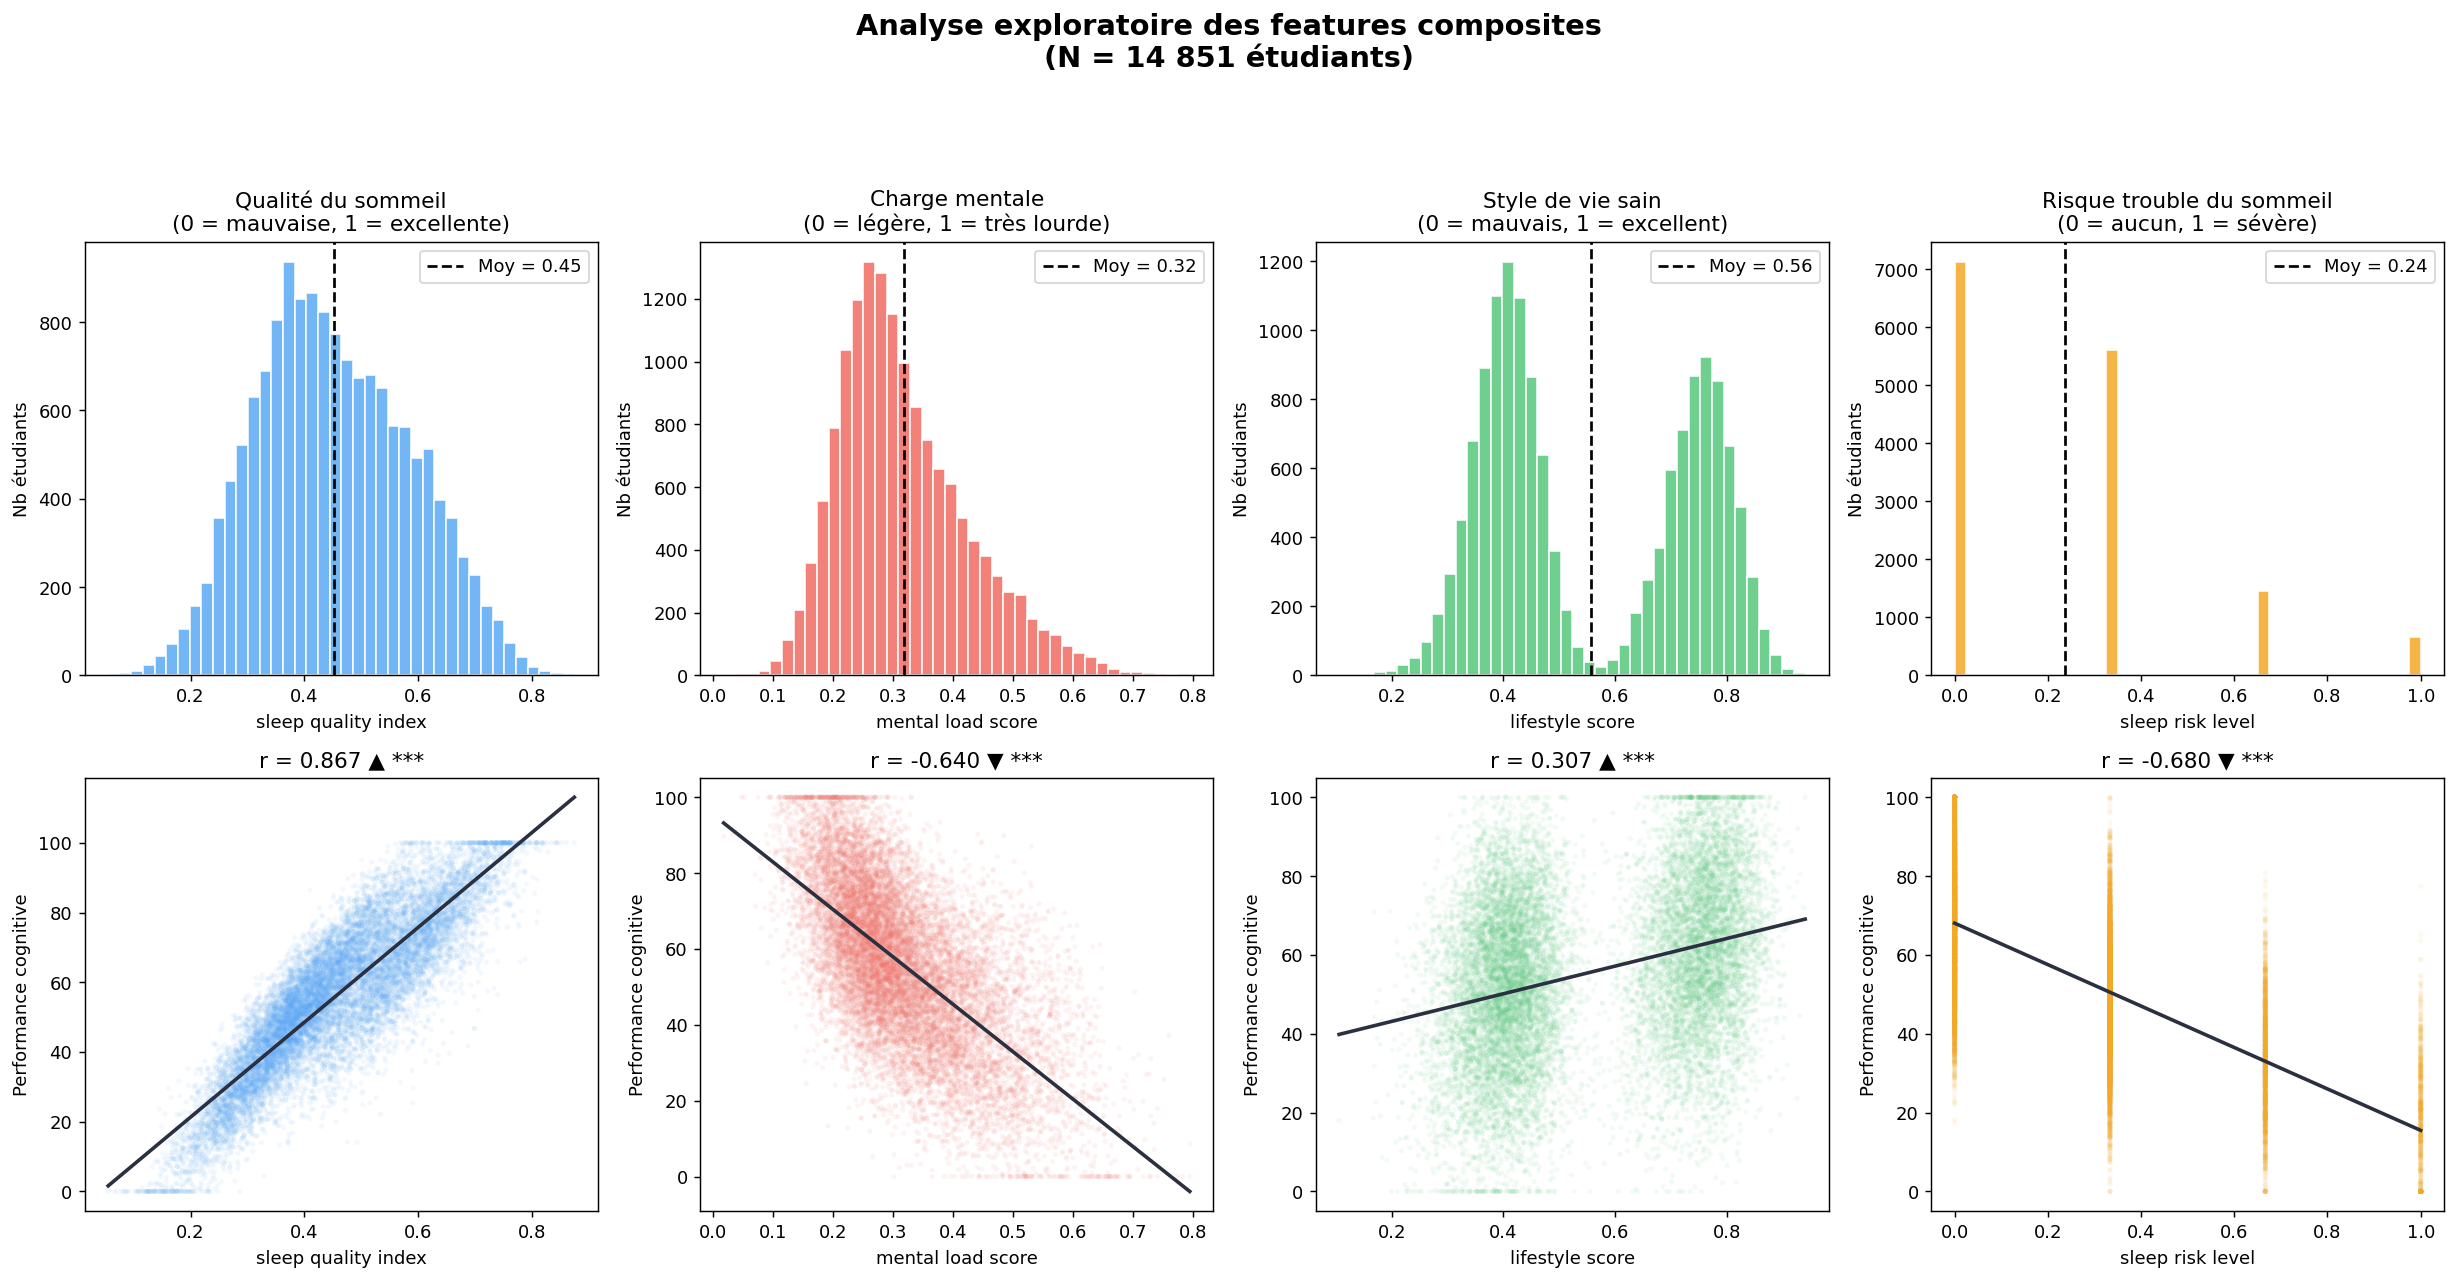

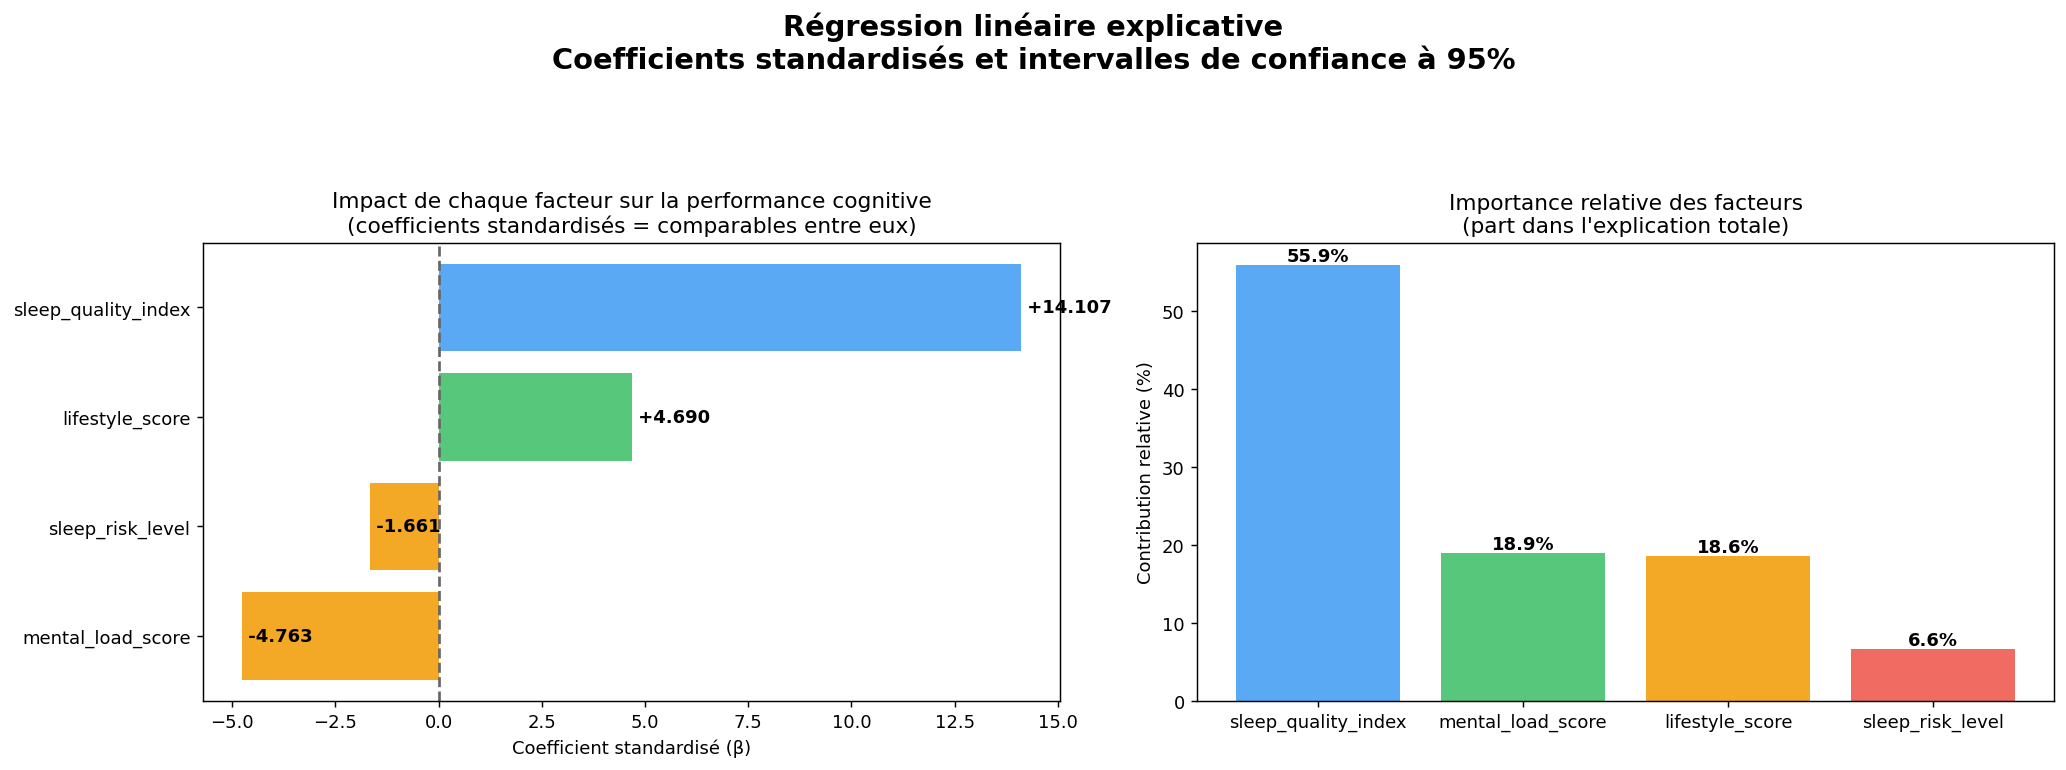

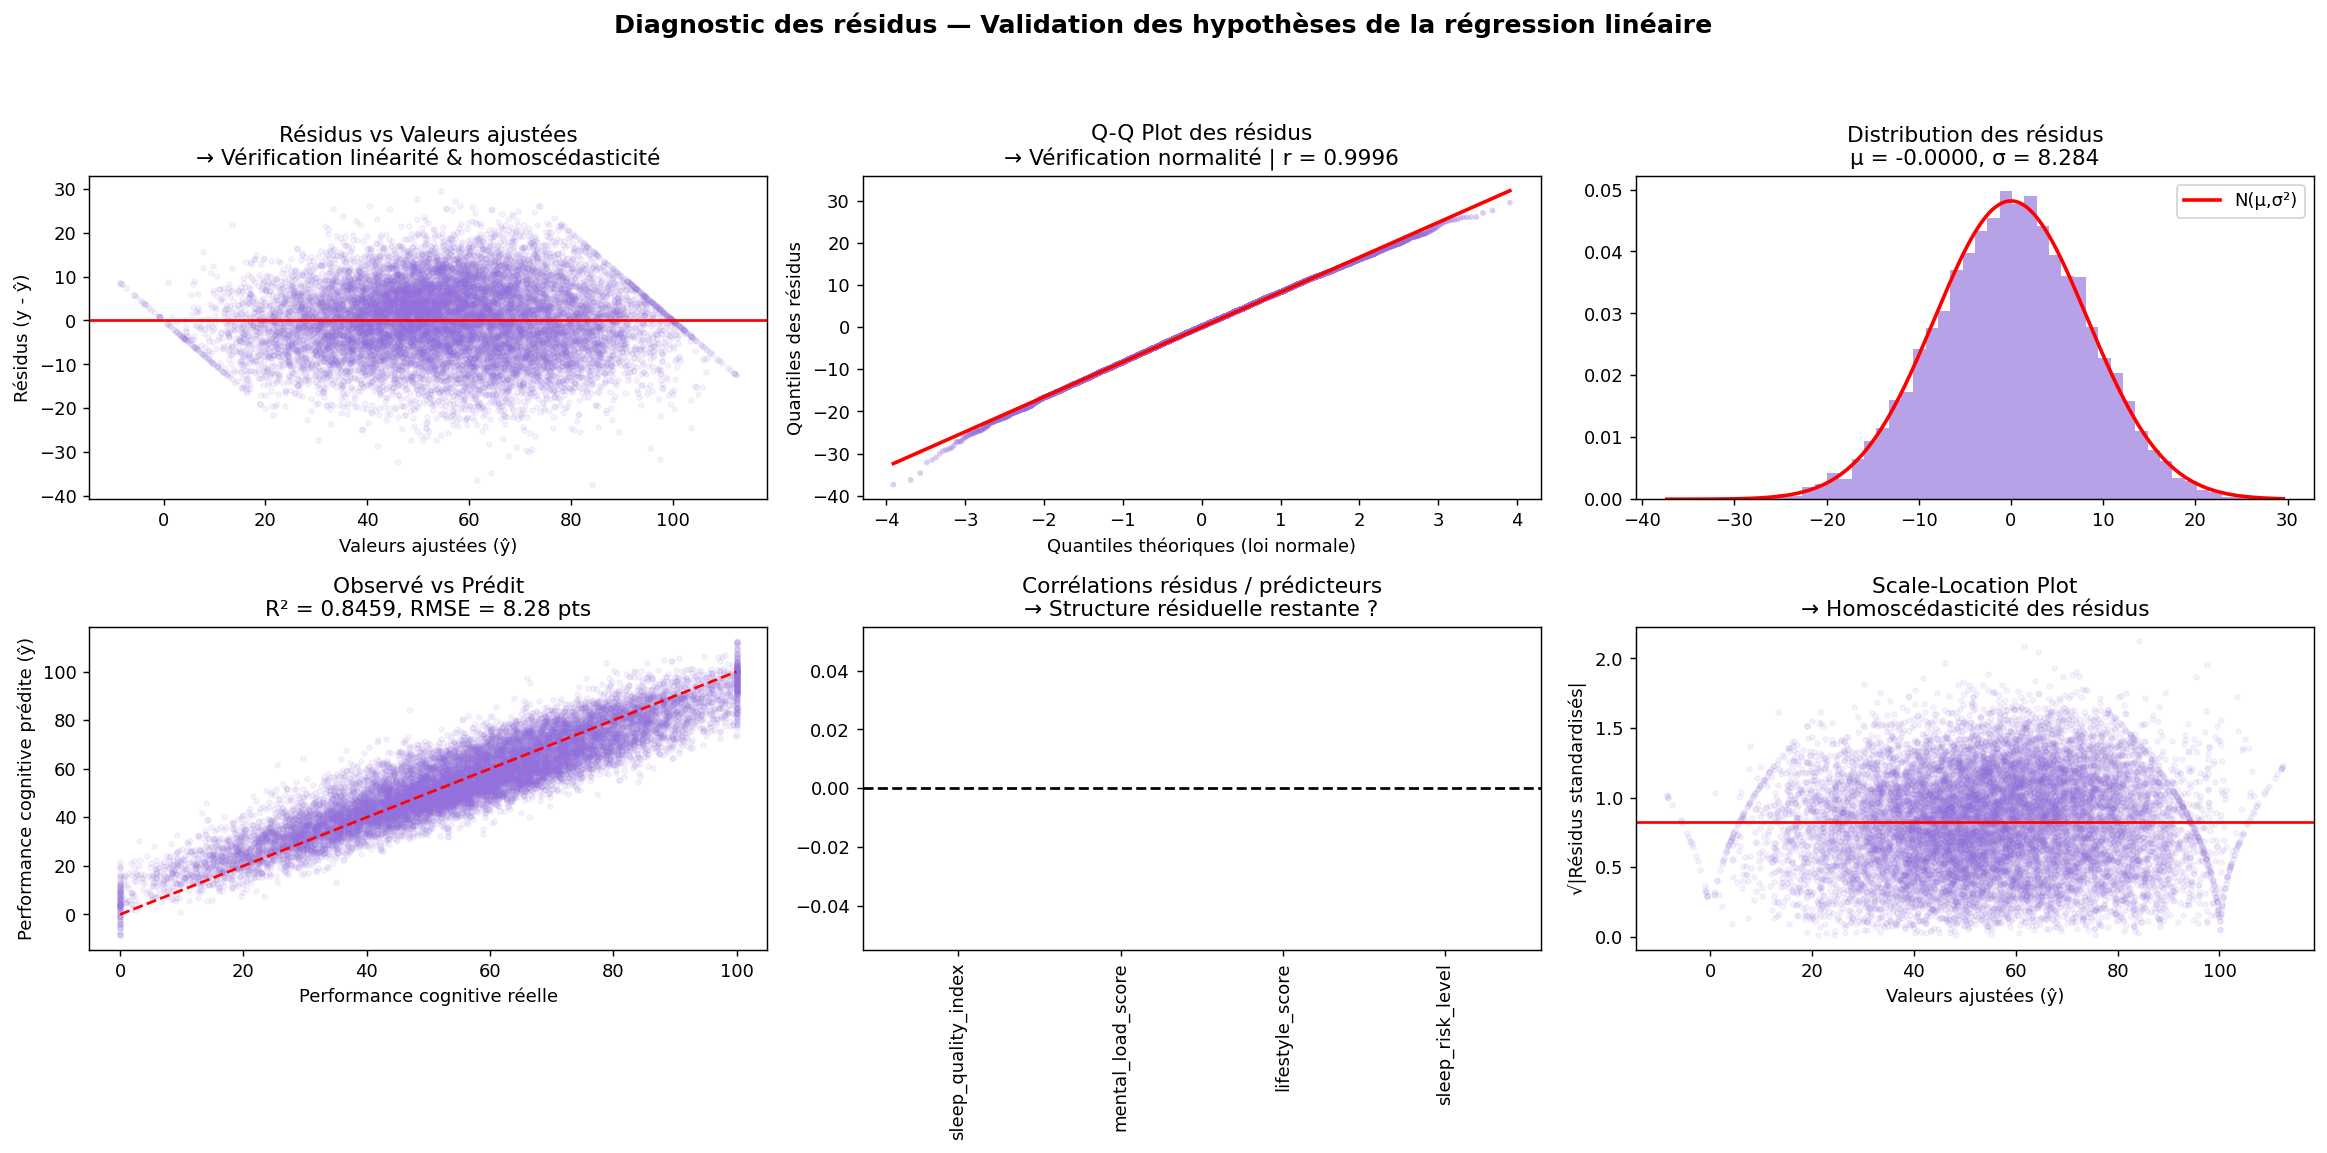

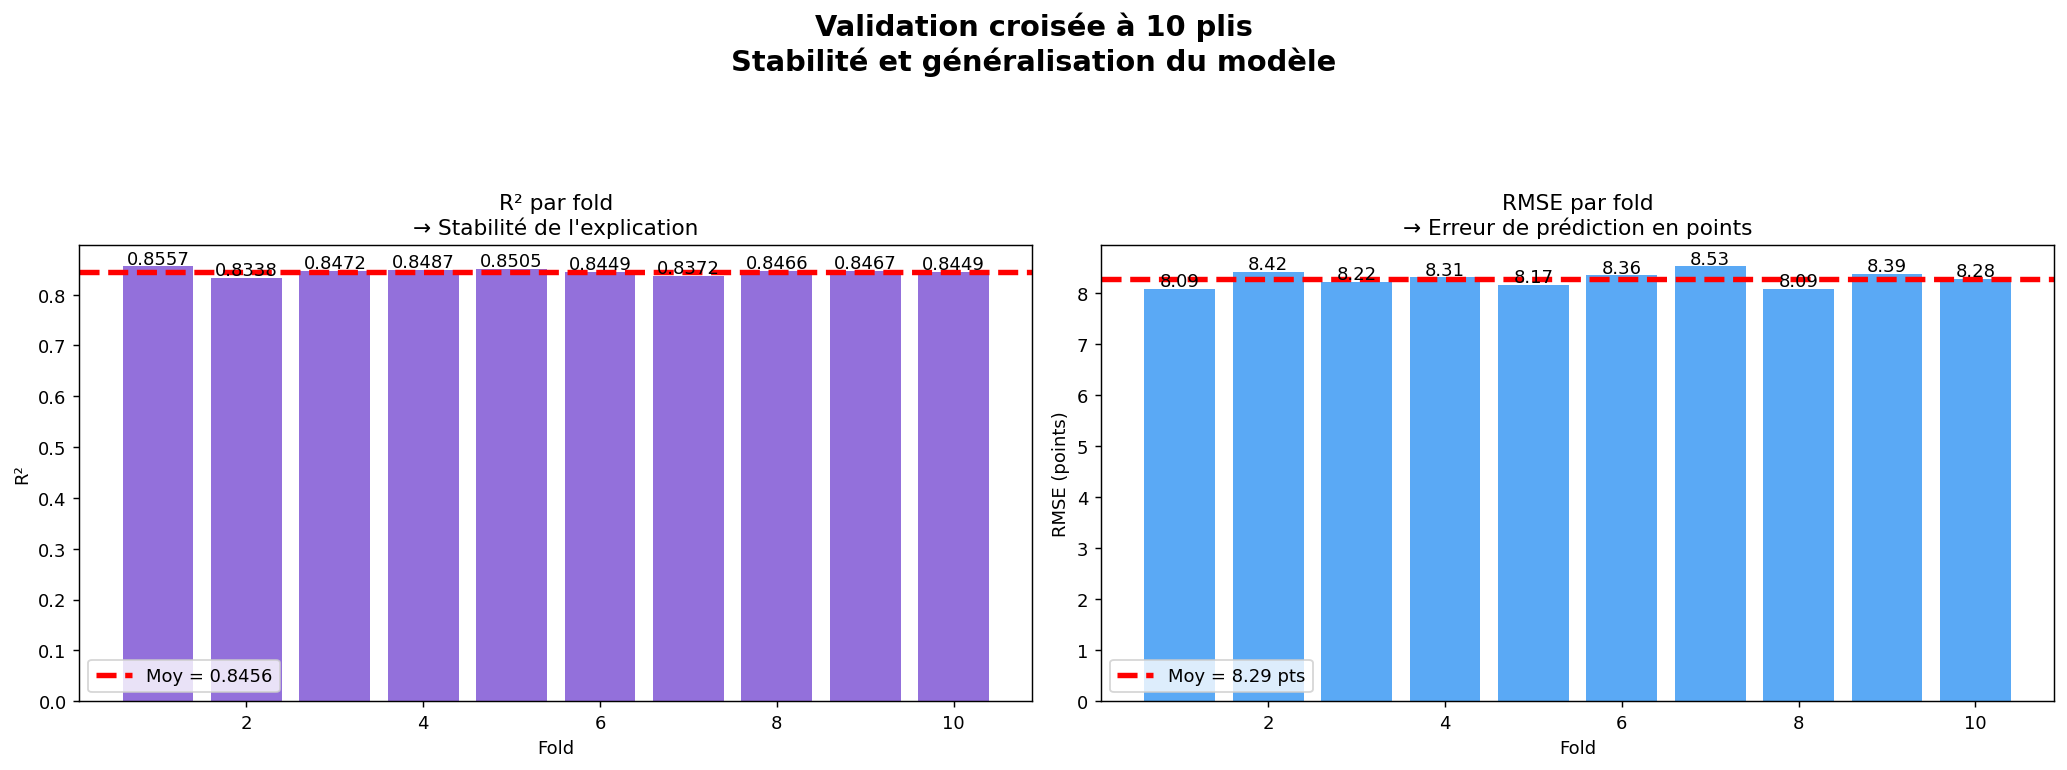

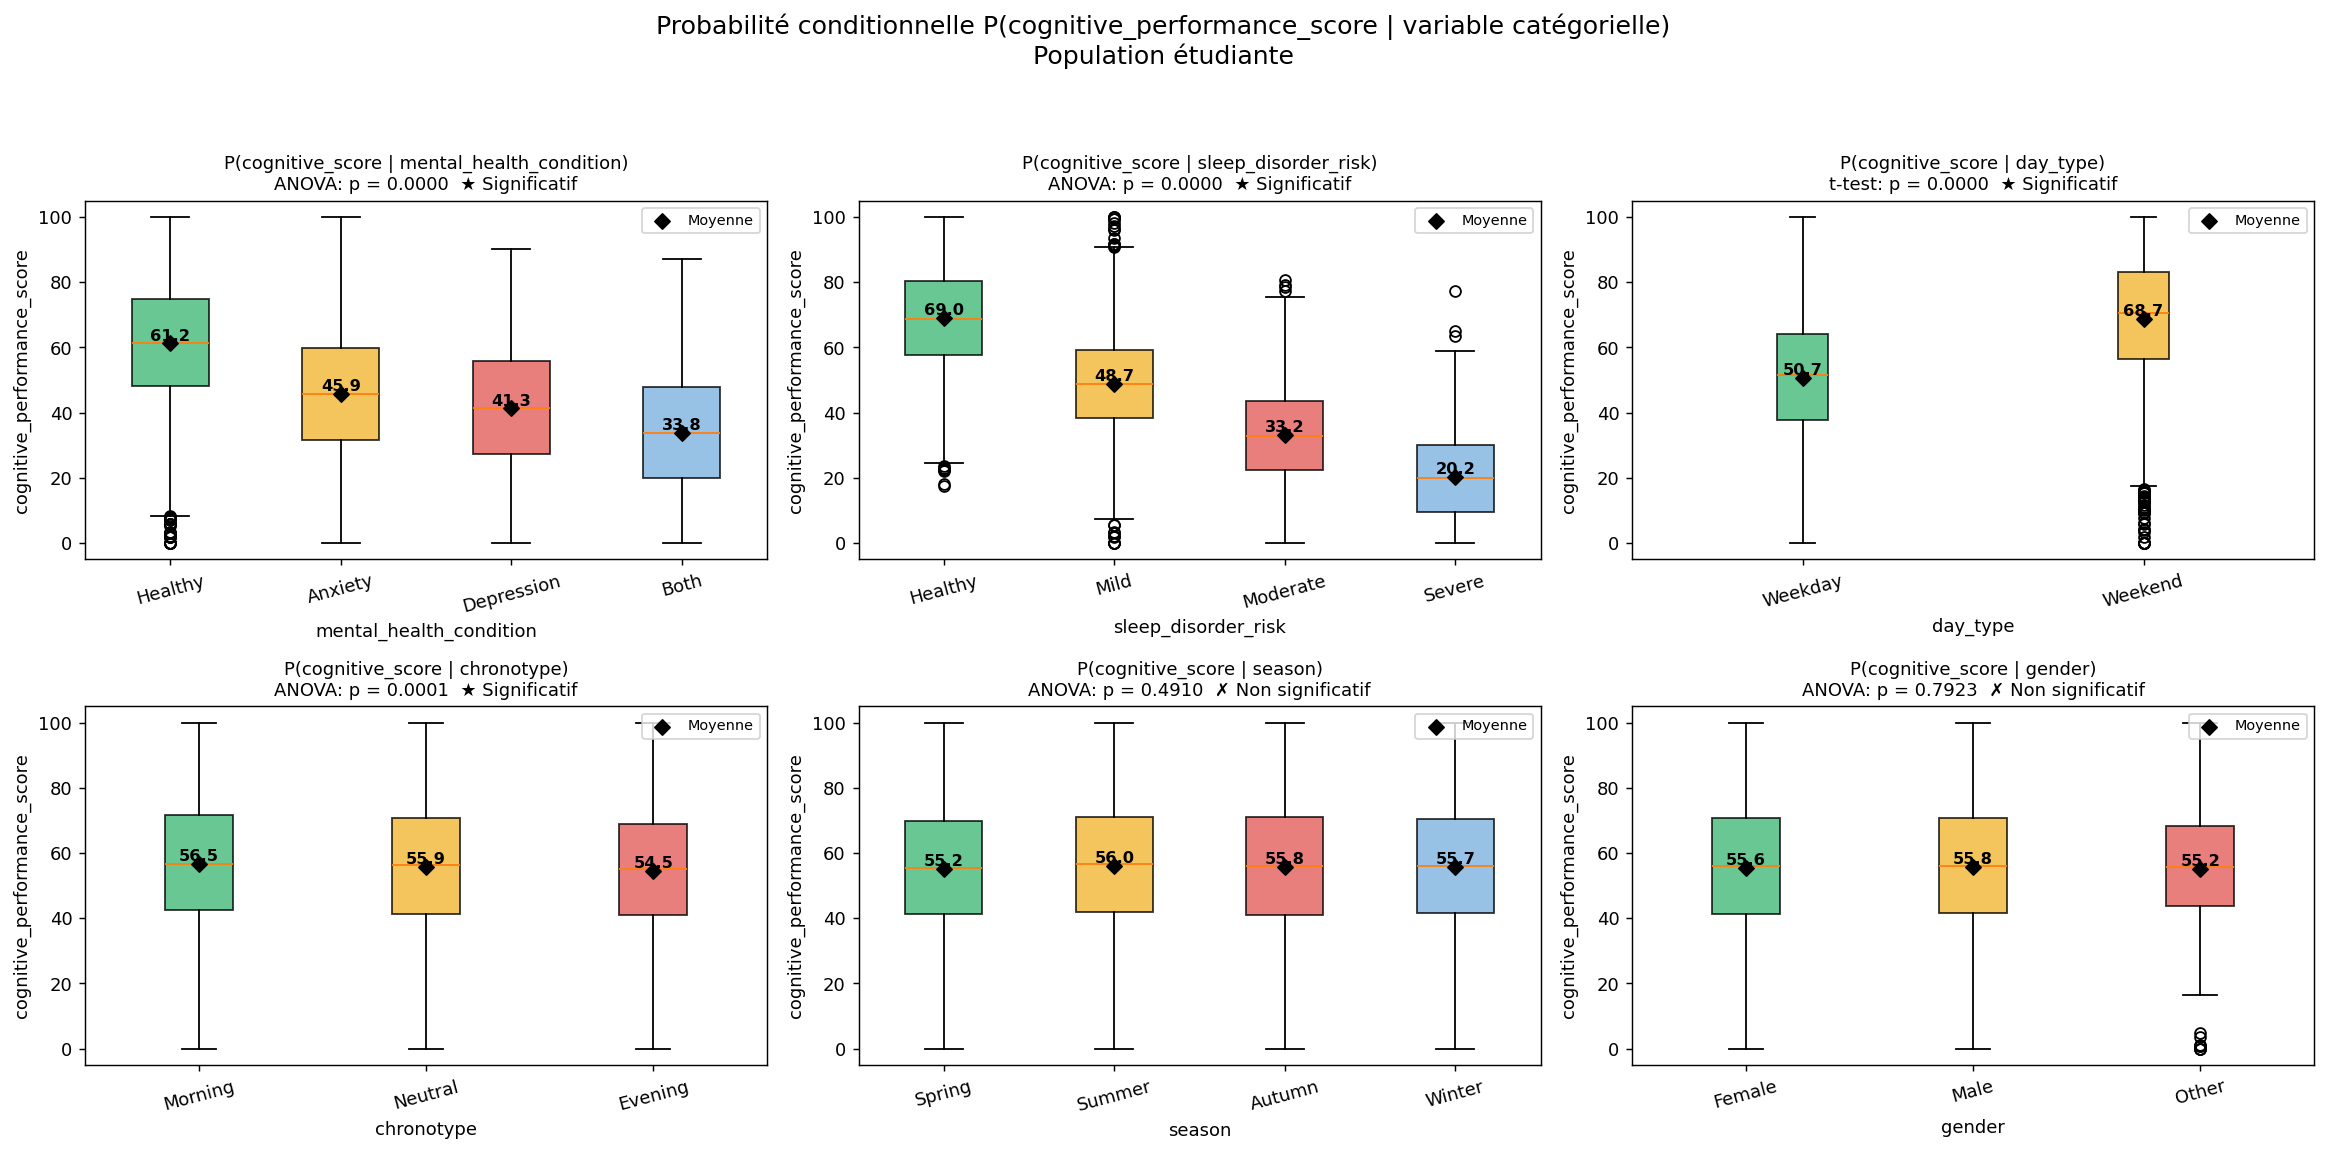

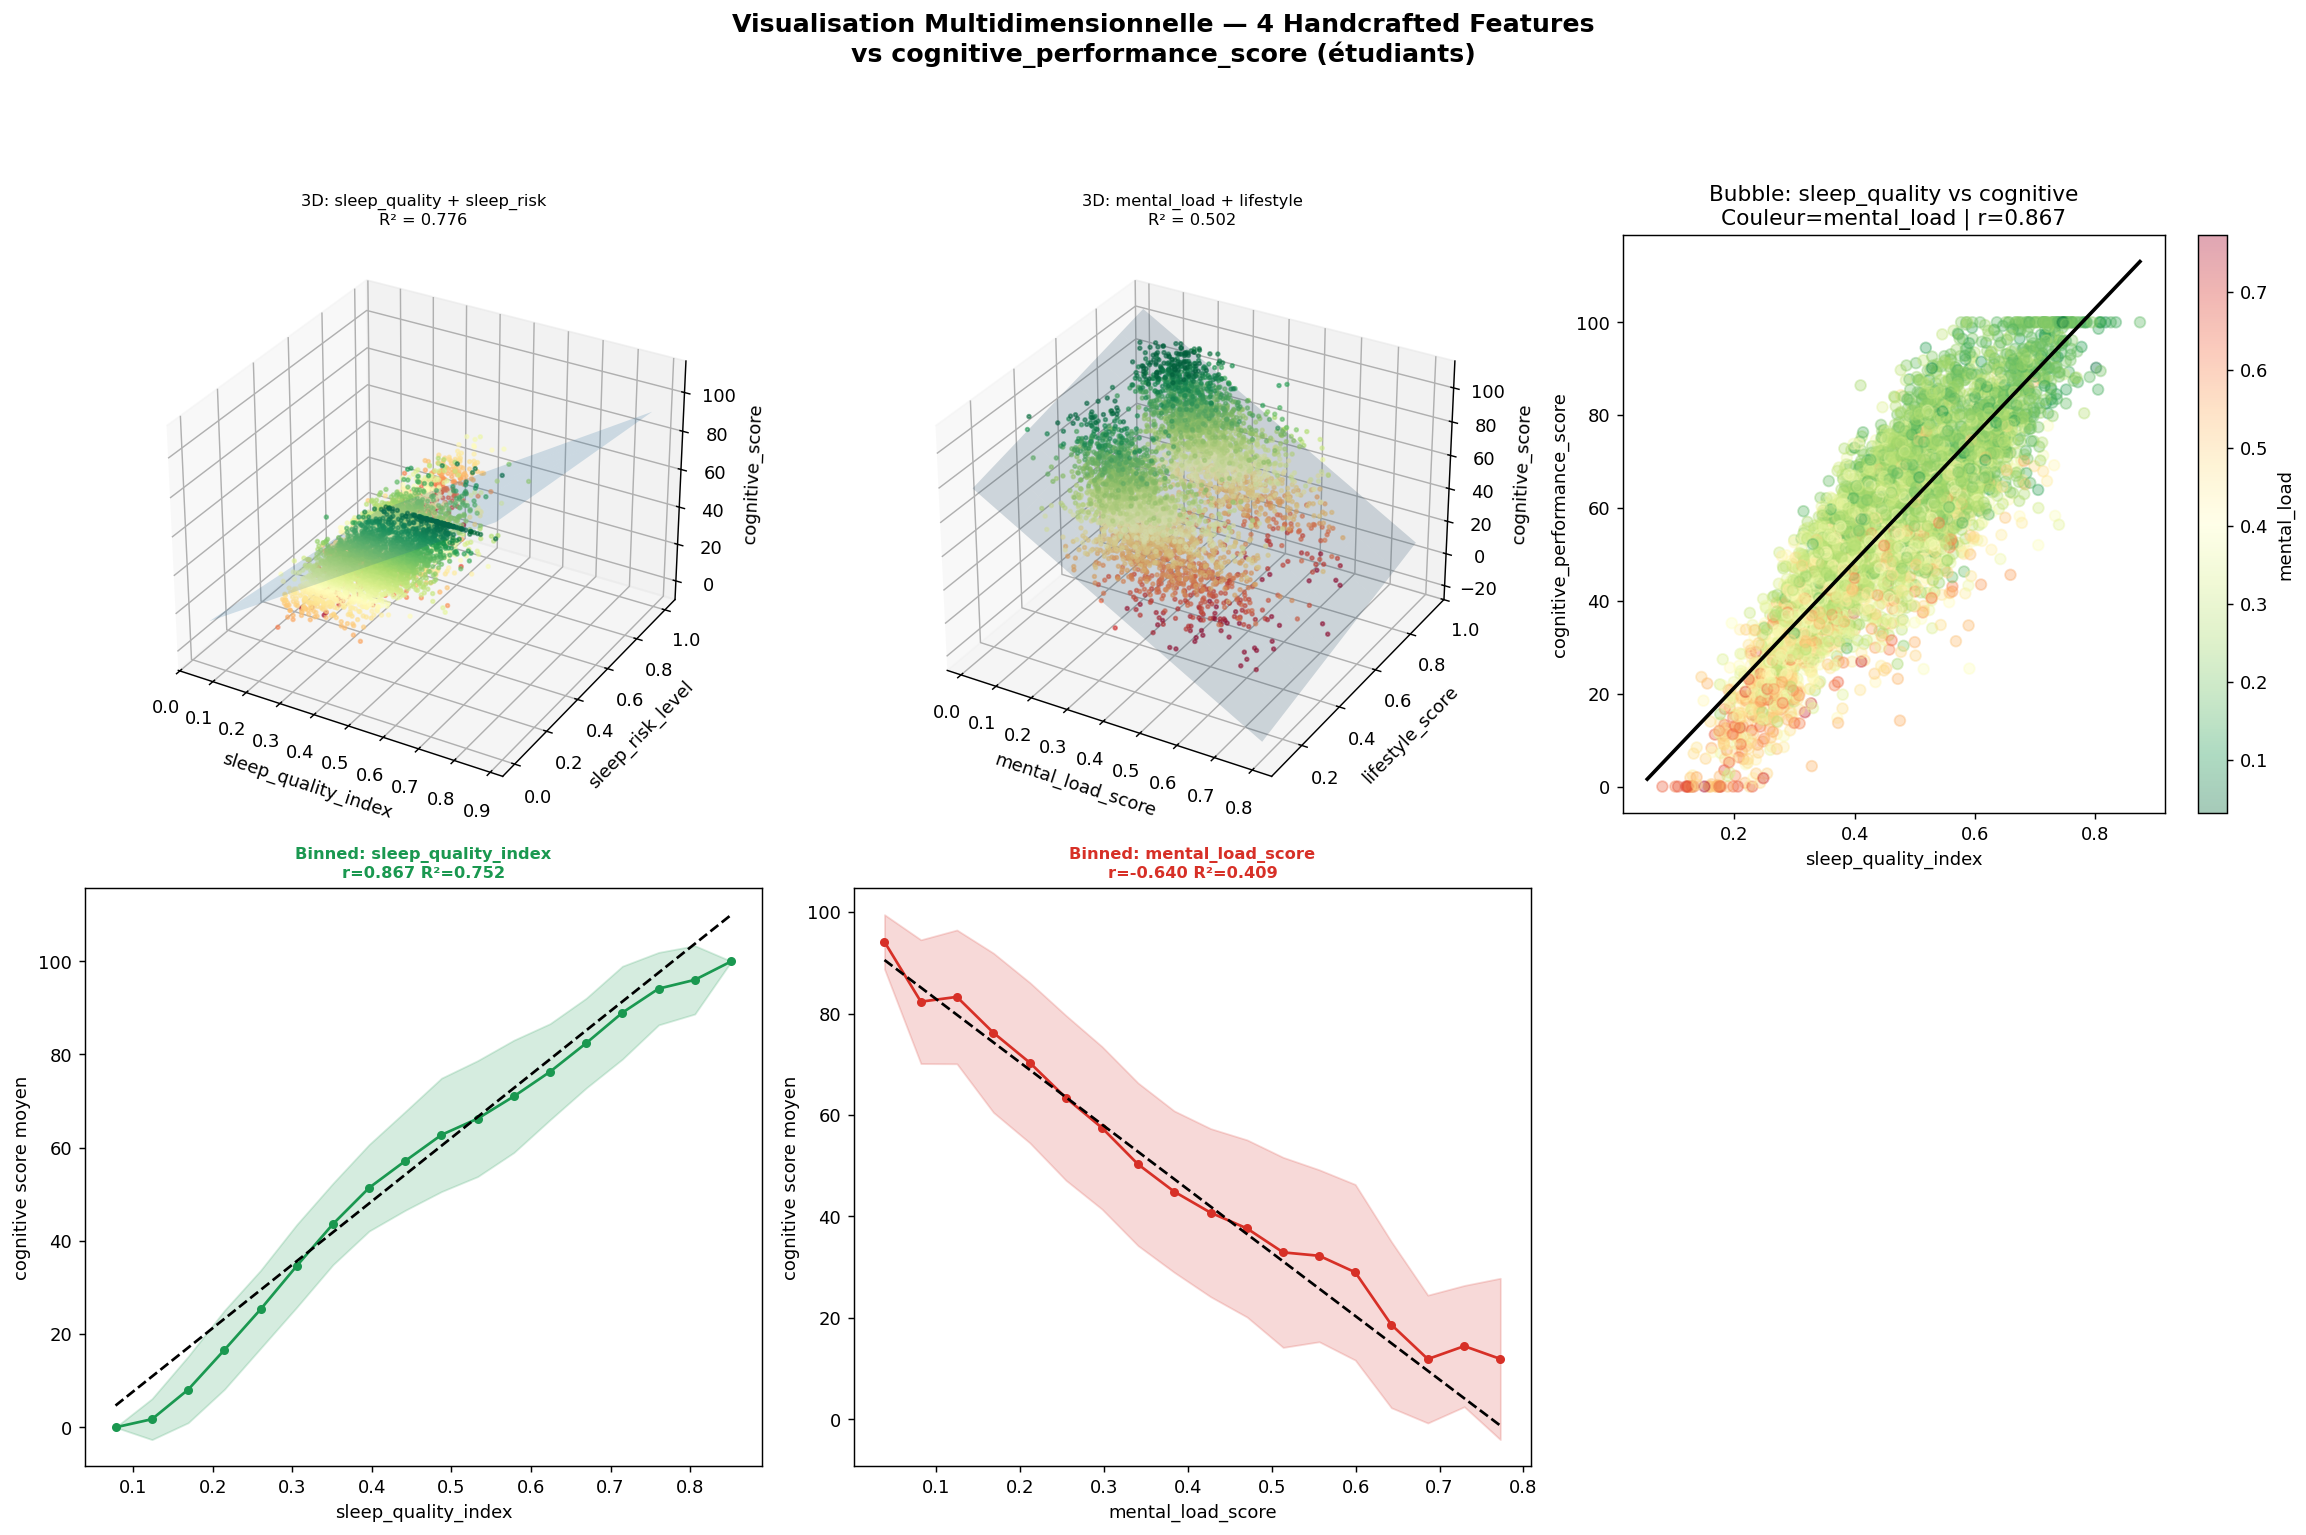

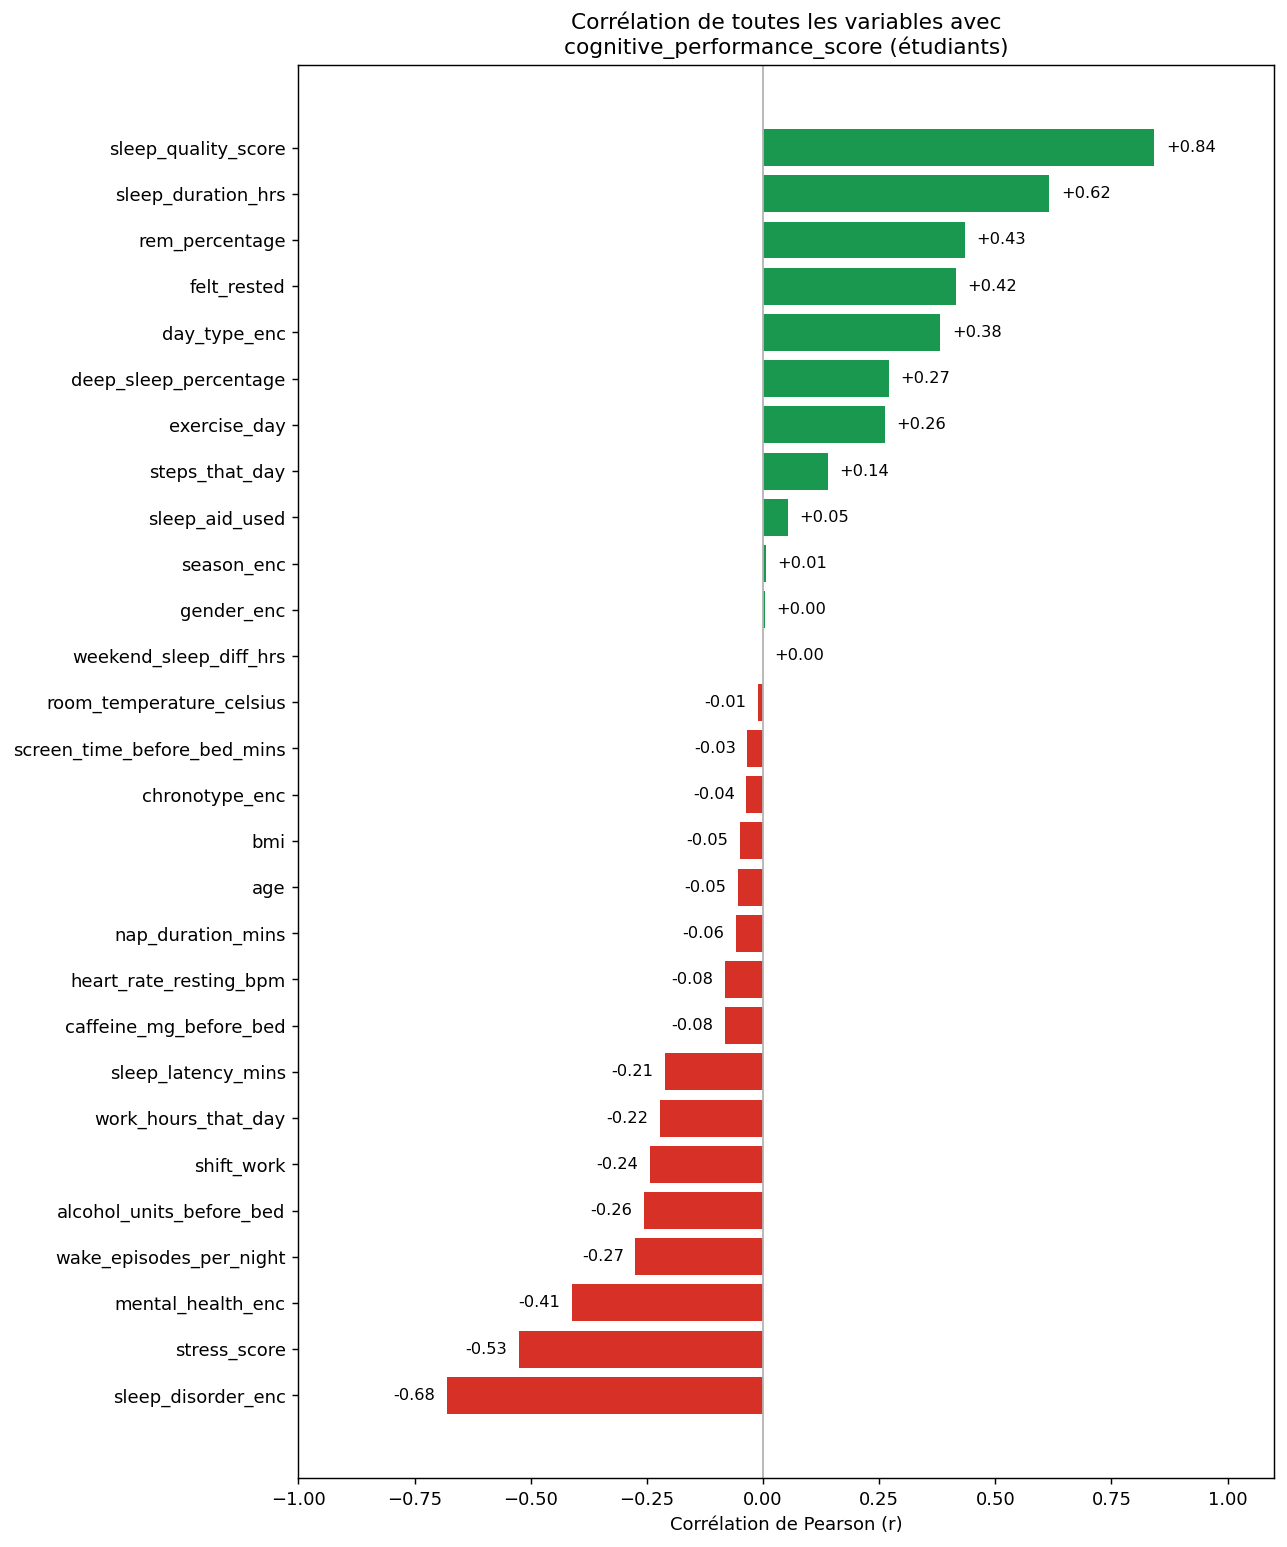

Done. Figures saved in: C:\Users\ThinkPad\Desktop\Data_processing\figures


In [15]:
def generate_all_figures(d):
    fig_exploration(d)
    fig_coefficients(d)
    fig_residus(d)
    fig_crossval(d)
    fig_conditional_probability(d)
    fig_multidimensional(d)
    fig_all_correlations(d)


generate_all_figures(d)
print("Done. Figures saved in:", OUT_DIR.resolve())

## 5. Check saved files

In [16]:
expected = [
    "fig1_exploration.png",
    "fig2_coefficients.png",
    "fig3_residus.png",
    "fig4_crossval.png",
    "fig_conditional_probability.png",
    "fig_multidimensional.png",
    "fig_all_correlations.png",
]

for name in expected:
    p = OUT_DIR / name
    print(("OK:      " if p.exists() else "Missing: "), p)

OK:       C:\Users\ThinkPad\Desktop\Data_processing\figures\fig1_exploration.png
OK:       C:\Users\ThinkPad\Desktop\Data_processing\figures\fig2_coefficients.png
OK:       C:\Users\ThinkPad\Desktop\Data_processing\figures\fig3_residus.png
OK:       C:\Users\ThinkPad\Desktop\Data_processing\figures\fig4_crossval.png
OK:       C:\Users\ThinkPad\Desktop\Data_processing\figures\fig_conditional_probability.png
OK:       C:\Users\ThinkPad\Desktop\Data_processing\figures\fig_multidimensional.png
OK:       C:\Users\ThinkPad\Desktop\Data_processing\figures\fig_all_correlations.png
